# Classification

In [39]:
import pandas as pd

data = pd.read_csv("/content/students_data.csv")

print(data.head())
print(data.info())

   study_hours  attendance  assignments_completed  previous_score  \
0            7          50                      8              50   
1            4          60                      4              99   
2            8          77                      0              76   
3            5          74                      9              75   
4            7          99                      9              74   

   sleep_hours  result  
0            8       1  
1            5       1  
2            8       1  
3            5       1  
4            8       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   study_hours            200 non-null    int64
 1   attendance             200 non-null    int64
 2   assignments_completed  200 non-null    int64
 3   previous_score         200 non-null    int64
 4   sleep_hours            200

In [40]:
print(data)

     study_hours  attendance  assignments_completed  previous_score  \
0              7          50                      8              50   
1              4          60                      4              99   
2              8          77                      0              76   
3              5          74                      9              75   
4              7          99                      9              74   
..           ...         ...                    ...             ...   
195            1          77                      5              56   
196            8          75                      9              49   
197            7          86                      4              56   
198            2          75                      5              99   
199            8          72                      4              59   

     sleep_hours  result  
0              8       1  
1              5       1  
2              8       1  
3              5       1  
4           

In [41]:
X = data.drop("result", axis=1)
y = data["result"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
from sklearn.metrics import *

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [46]:
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix is : \n",cm)
#[TN FP]
#[FN TP]

confusion matrix is : 
 [[21  0]
 [ 2 17]]


In [47]:
import numpy as np

In [48]:
def accuracy(cm):
    return (cm[0][0] + cm[1][1]) / np.sum(cm)

print("Accuracy:", accuracy(cm))

#Out of all predictions, 95% are correct.

Accuracy: 0.95


In [49]:
def precision(cm):
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    precision = TP/(TP+FP)

    return precision,
print(precision(cm))

#Out of all the positive predictions made by the model, 100% are correct.

(np.float64(1.0),)


In [50]:
def recall(cm):
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    recall  = TP/(TP+FN)

    return recall,
print(recall(cm))

#Out of all the actual positive cases, 89% are correctly identified by the model.

(np.float64(0.8947368421052632),)


In [51]:
def FPR(cm):
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    FPR = FP/(FP+TN)

    return FPR,
print(FPR(cm))

#model makes no false positive errors.

(np.float64(0.0),)


In [57]:
def fbeta(cm,beta):
    TP = cm[1][1]
    FP = cm[0][1]
    FN = cm[1][0]

    precision = TP/(TP+FP)
    recall    = TP/(TP+FN)

    return (1+beta**2)*(precision*recall)/((beta**2*precision)+recall)

for b in [0.5,1,2]:
    print("Fbeta ",b,":",fbeta(cm,b))

# Fbeta(0.5) = means the model performs very well when precision is given more importance.

# Fbeta(1) = means the model has a good balance between precison and recall.

# Fbeta(2) = means the model performs slightly lower when recall is given more importance.


Fbeta  0.5 : 0.9770114942528735
Fbeta  1 : 0.9444444444444444
Fbeta  2 : 0.913978494623656


AUC: 0.949874686716792


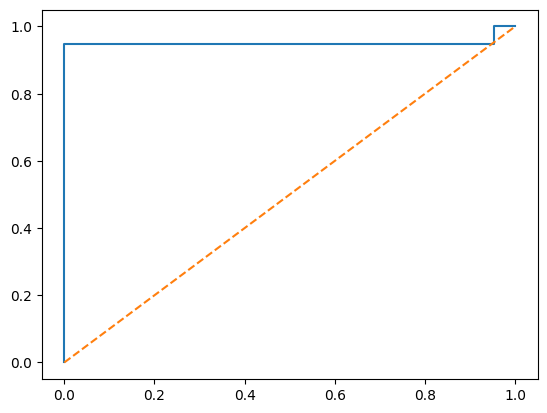

In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr,_= roc_curve(y_test, prob)
print("AUC:", auc(fpr, tpr))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], '--')
plt.show()

# Model has excellent ability to distinguish between positive and negative classes.


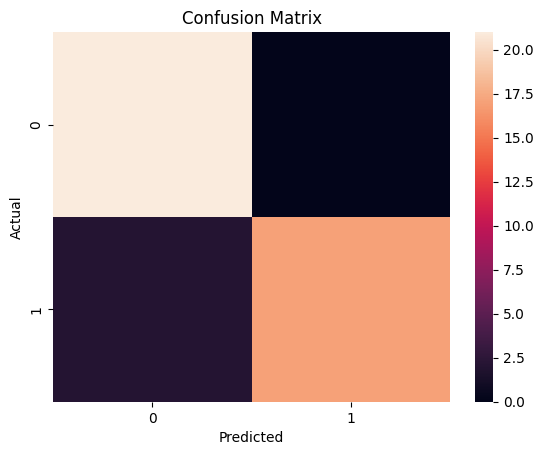

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

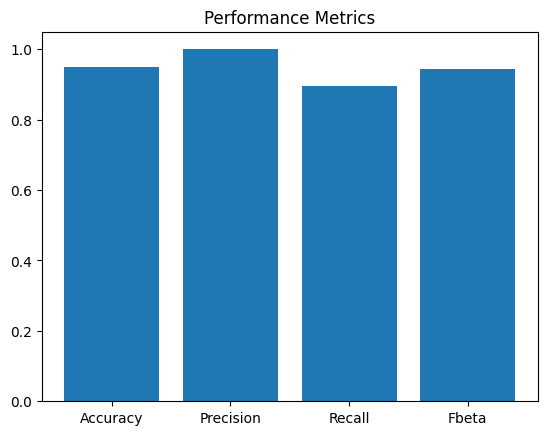

In [55]:
metrics = ['Accuracy','Precision','Recall','Fbeta']
values = [accuracy(cm), precision(cm)[0], recall(cm)[0], fbeta(cm, 1)]

plt.figure()
plt.bar(metrics, values)
plt.title("Performance Metrics")
plt.show()